# Capítulo 6 – Modelo Final y Evaluación con Validación Cruzada
## Sistema de Bicicletas Compartidas – Dataset `hour_prepared.csv`

En este capítulo construiremos un **modelo final de regresión lineal múltiple** para la demanda horaria de bicicletas (`cnt`).

Usaremos el dataset preparado en el Capítulo 2 (`hour_prepared.csv`), y:

- Seleccionaremos un subconjunto de variables mediante **selección forward basada en AIC**.
- Ajustaremos el modelo final con todas las observaciones.
- Evaluaremos su desempeño usando **validación cruzada K-fold (K = 5)**.
- Analizaremos gráficos básicos de ajuste del modelo final.


## 1. Carga de librerías y datos

Cargamos el dataset ya preparado que contiene las variables numéricas y dummies listas para modelar.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11


In [13]:
# Ruta relativa al dataset preparado
data_path = "../data/hour_prepared.csv"
df_model = pd.read_csv(data_path)
df_model.head()

,temp,atemp,hum,windspeed,peak_hour,hr_1,hr_2,hr_3,hr_4,hr_5,...,weekday_6,workingday_1,season_2,season_3,season_4,yr_1,weathersit_2,weathersit_3,weathersit_4,cnt
0,0.24,0.2879,0.81,0.0,0,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,16
1,0.22,0.2727,0.80,0.0,0,True,False,False,False,False,...,True,False,False,False,False,False,False,False,False,40
2,0.22,0.2727,0.80,0.0,0,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,32
3,0.24,0.2879,0.75,0.0,0,False,False,True,False,False,...,True,False,False,False,False,False,False,False,False,13
4,0.24,0.2879,0.75,0.0,0,False,False,False,True,False,...,True,False,False,False,False,False,False,False,False,1


Verificamos dimensiones y ausencia de valores faltantes.


In [14]:
df_model.shape

(17379, 43)

In [15]:
df_model.isna().sum().sum()

np.int64(0)

## 2. Definición de la variable objetivo y predictores

La variable objetivo es `cnt` y los predictores son todas las demás columnas del dataset.


In [16]:
target_col = "cnt"
if target_col not in df_model.columns:
    raise ValueError("La columna 'cnt' no se encuentra en 'hour_prepared.csv'.")

y = df_model["cnt"].astype(float)
X_full = df_model.drop(columns=["cnt"])

X_full = X_full.select_dtypes(include=["number"]).astype(float)

X_full.shape, X_full.dtypes.head()

((17379, 5),
 temp         float64
 atemp        float64
 hum          float64
 windspeed    float64
 peak_hour    float64
 dtype: object)

## 3. Selección de variables mediante Forward Selection (AIC)

Implementamos un procedimiento de **selección forward** usando el criterio AIC:

1. Comenzamos sin predictores.
2. En cada paso, probamos agregar cada variable candidata restante.
3. Elegimos la que produce el menor AIC.
4. Si el AIC mejora respecto al modelo anterior, la añadimos al conjunto.
5. Repetimos hasta que añadir nuevas variables ya no mejore el AIC.


In [17]:
def fit_ols_add_const(X, y):
    X_const = sm.add_constant(X, has_constant='add')
    model = sm.OLS(y, X_const).fit()
    return model

all_predictors = list(X_full.columns)
selected_vars = []
current_aic = None
history = []

while True:
    remaining = [v for v in all_predictors if v not in selected_vars]
    if not remaining:
        break
    trial_results = []
    for var in remaining:
        vars_trial = selected_vars + [var]
        model_trial = fit_ols_add_const(X_full[vars_trial], y)
        trial_results.append((model_trial.aic, var, model_trial))
    trial_results.sort(key=lambda x: x[0])
    best_aic, best_var, best_model = trial_results[0]
    if current_aic is None or best_aic < current_aic - 1e-6:
        selected_vars.append(best_var)
        current_aic = best_aic
        history.append((len(selected_vars), best_var, best_aic))
    else:
        break

selected_vars, current_aic

(['peak_hour', 'temp', 'hum', 'atemp', 'windspeed'],
 np.float64(219663.1225741774))

In [18]:
history_df = pd.DataFrame(history, columns=["k", "variable_agregada", "AIC"])
history_df

,k,variable_agregada,AIC
0,1,peak_hour,226076.264284
1,2,temp,222107.723827
2,3,hum,219719.131106
3,4,atemp,219663.313445
4,5,windspeed,219663.122574


El conjunto de variables seleccionadas por AIC será la base de nuestro **modelo final**.


In [19]:
X_sel = X_full[selected_vars].copy()
X_sel.shape

(17379, 5)

## 4. Ajuste del modelo final con todas las observaciones

Ajustamos el modelo OLS usando **todas las observaciones** y solo las variables seleccionadas.


In [20]:
X_sel_const = sm.add_constant(X_sel, has_constant='add')
model_final = sm.OLS(y, X_sel_const).fit()
model_final

Mostramos el resumen del modelo final:


In [21]:
model_final.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.451
Model:                            OLS   Adj. R-squared:                  0.451
Method:                 Least Squares   F-statistic:                     2858.
Date:                Sat, 29 Nov 2025   Prob (F-statistic):               0.00
Time:                        02:44:58   Log-Likelihood:            -1.0983e+05
No. Observations:               17379   AIC:                         2.197e+05
Df Residuals:                   17373   BIC:                         2.197e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        119.3387      5.603     21.299      0.000     108.356     130.321
peak_hour    186.2537      2.353     79.161      0.000     181.642     190.866
temp          93.0452     34.936      2.663      0.008      24.567     161.524
hum         -270.8086      5.543    -48.853      0.000    -281.674    -259.943
atemp        303.5389     39.191      7.745      0.000     226.720     380.357
windspeed     13.2718      8.968      1.480      0.139      -4.306      30.849
==============================================================================
Omnibus:                     2110.731   Durbin-Watson:                   0.523
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3527.659
Skew:                           0.839   Prob(JB):                         0.00
Kurtosis:                       4.435   Cond. No.                         72.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### 4.1. Tabla de coeficientes del modelo final

Construimos una tabla con coeficientes, errores estándar, estadísticos t, valores-p e intervalos de confianza al 95%.


In [22]:
conf_int = model_final.conf_int(alpha=0.05)
conf_int.columns = ["IC 2.5%", "IC 97.5%"]

coef_table = pd.DataFrame({
    "coef": model_final.params,
    "std err": model_final.bse,
    "t": model_final.tvalues,
    "P>|t|": model_final.pvalues,
})
coef_table = pd.concat([coef_table, conf_int], axis=1)
coef_table.index.name = "Parámetro"
coef_table.round(4)

,coef,std err,t,P>|t|,IC 2.5%,IC 97.5%
Parámetro,,,,,,
const,119.3387,5.6031,21.2989,0.0000,108.3561,130.3212
peak_hour,186.2537,2.3529,79.1606,0.0000,181.6418,190.8655
temp,93.0452,34.9362,2.6633,0.0077,24.5666,161.5237
hum,-270.8086,5.5433,-48.8533,0.0000,-281.6740,-259.9431
atemp,303.5389,39.1911,7.7451,0.0000,226.7205,380.3574
windspeed,13.2718,8.9677,1.4800,0.1389,-4.3058,30.8494


## 5. Validación cruzada K-fold (K = 5)

Para evaluar la capacidad de generalización del modelo final realizamos una validación cruzada K-fold con K = 5. En cada partición:

1. Ajustamos el modelo en el conjunto de entrenamiento.
2. Calculamos el RMSE en el conjunto de validación.
3. Promediamos los RMSE de las 5 particiones.


In [23]:
def cv_rmse_ols(X, y, k=5, random_state=123):
    kf = KFold(n_splits=k, shuffle=True, random_state=random_state)
    rmses = []
    for train_idx, test_idx in kf.split(X):
        X_train_cv = X.iloc[train_idx]
        y_train_cv = y.iloc[train_idx]
        X_test_cv = X.iloc[test_idx]
        y_test_cv = y.iloc[test_idx]

        X_train_cv_const = sm.add_constant(X_train_cv, has_constant='add')
        X_test_cv_const = sm.add_constant(X_test_cv, has_constant='add')
        model_cv = sm.OLS(y_train_cv, X_train_cv_const).fit()
        y_pred_cv = model_cv.predict(X_test_cv_const)
        rmse_cv = np.sqrt(mean_squared_error(y_test_cv, y_pred_cv))
        rmses.append(rmse_cv)
    return np.mean(rmses), np.std(rmses)

mean_rmse_cv, std_rmse_cv = cv_rmse_ols(X_sel, y, k=5)
mean_rmse_cv, std_rmse_cv

(np.float64(134.39140769306715), np.float64(1.2495493592320743))

También calculamos las métricas **in-sample** (usando todas las observaciones):


In [24]:
y_pred_full = model_final.predict(X_sel_const)
rmse_full = np.sqrt(mean_squared_error(y, y_pred_full))
r2_full = r2_score(y, y_pred_full)

metrics_final = pd.DataFrame({
    "RMSE": [rmse_full, mean_rmse_cv],
    "R2": [r2_full, np.nan],
}, index=["Full sample", "CV (mean)"])
metrics_final.round(4)

,RMSE,R2
Full sample,134.3572,0.4513
CV (mean),134.3914,NaN


## 6. Gráficos de ajuste del modelo final

Para complementar el análisis numérico, mostramos:

- Diagrama de dispersión `cnt observado` vs `cnt predicho`.
- Gráfico de residuales vs valores ajustados.


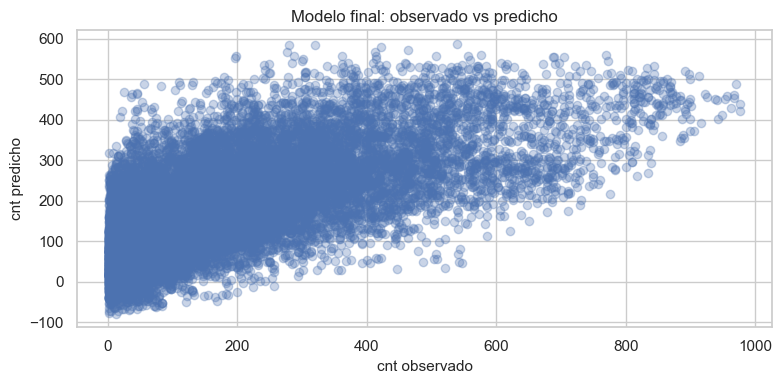

In [25]:
# Observado vs predicho
fig, ax = plt.subplots()
ax.scatter(y, y_pred_full, alpha=0.3)
ax.set_xlabel("cnt observado")
ax.set_ylabel("cnt predicho")
ax.set_title("Modelo final: observado vs predicho")
plt.tight_layout()
plt.show()

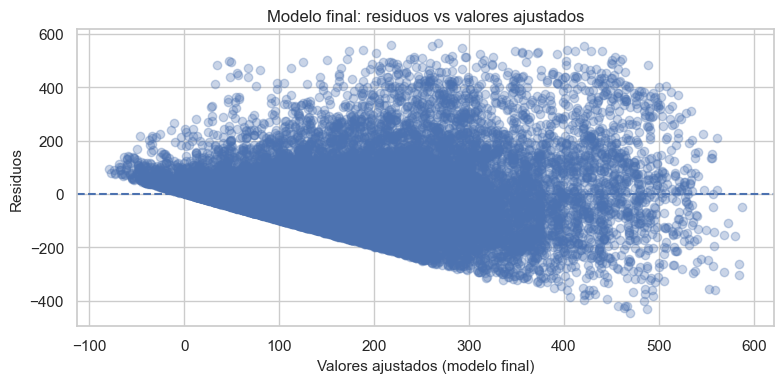

In [26]:
# Residuos vs valores ajustados
residuals_full = y - y_pred_full
fig, ax = plt.subplots()
ax.scatter(y_pred_full, residuals_full, alpha=0.3)
ax.axhline(0, linestyle='--')
ax.set_xlabel("Valores ajustados (modelo final)")
ax.set_ylabel("Residuos")
ax.set_title("Modelo final: residuos vs valores ajustados")
plt.tight_layout()
plt.show()

## 7. Conclusiones del modelo final

En este capítulo:

- Aplicamos **selección forward basada en AIC** para escoger un subconjunto de variables explicativas a partir de `hour_prepared.csv`.
- Ajustamos un **modelo final de regresión lineal múltiple** con todas las observaciones.
- Calculamos métricas de ajuste global (RMSE y R² en la muestra completa).
- Evaluamos la capacidad de generalización mediante **validación cruzada K-fold**.
- Visualizamos el desempeño del modelo final mediante gráficos de observado vs predicho y residuales vs ajustados.

En capítulos posteriores se podrían explorar extensiones como:

- Inclusión de términos polinómicos o interacciones.
- Modelos regularizados (Ridge, Lasso, ElasticNet).
- Modelos no lineales o basados en árboles de decisión.
